### Load Libraries

In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance


### Load and Inspect Data

In [3]:
# Load Data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
display(df.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


### Encode Categorical Data

In [16]:
df_train = df.copy()
df_train['label'] = df_train['satisfaction'].apply(lambda x:1 if x == 'satisfied' else 0)

encode_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
df_encoded = pd.get_dummies(df[encode_cols], columns=encode_cols)
df_encoded = df_encoded.astype(int)

df_train = pd.concat([df_train, df_encoded], axis=1)

display(df_encoded.head())

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,1,0,0,1,0,0,1
1,0,1,0,1,1,0,1,0,0
2,1,0,1,0,1,0,1,0,0
3,1,0,1,0,1,0,1,0,0
4,0,1,1,0,1,0,1,0,0


In [17]:
# Drop unnecesaary columns
dropped_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
df_train = df_train.drop(dropped_cols, axis=1)

In [22]:
# Create train dataset
X_train = y_train = df_train[df_train['type'] == 'train']
X_train = X_train.drop(['type', 'label'], axis=1)
y_train = y_train['label']

# Create test dataset
X_test = y_test = df_train[df_train['type'] == 'test']
X_test = X_test.drop(['type', 'label'], axis=1)
y_test = y_test['label']

In [21]:
# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
# Evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.965
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.95      0.96     11365

    accuracy                           0.97     25893
   macro avg       0.97      0.96      0.96     25893
weighted avg       0.97      0.97      0.97     25893



### Visualize Model

In [35]:
def plot_feature_importance(model, importance_type, feature_names, n_features=10, figsize=(10,6)):
    # Get feature importances
    if importance_type == 'feature':
        importances = model.feature_importances_
    elif importance_type == 'permutation':
        importances = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42).importances_mean
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    
    # Plot top n_features
    plt.figure(figsize=figsize)
    plt.title('Top Feature Importances in Airline Satisfaction Prediction')
    
    # Plot only top n_features
    n = min(n_features, len(importances))
    plt.bar(range(n), 
            importances[indices][:n],
            align='center')
    
    # Use actual words as labels
    plt.xticks(range(n), 
               [feature_names[i] for i in indices[:n]], 
               rotation=45,
               ha='right')
    
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.tight_layout()
    plt.show()

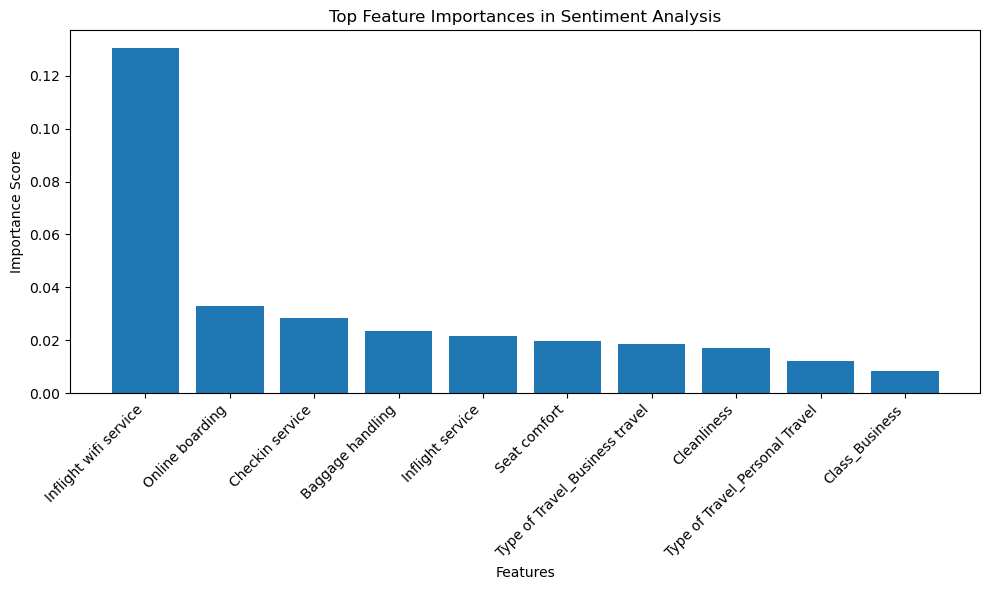

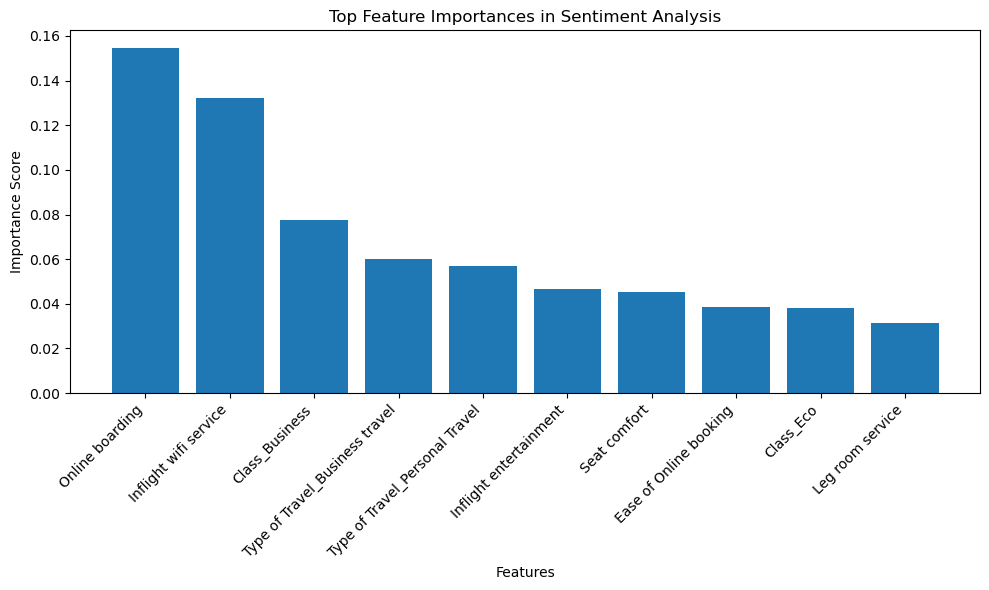

In [34]:
feature_names = X_train.columns
plot_feature_importance(model, 'permutation', feature_names)
plot_feature_importance(model, 'feature', feature_names)

### Breakdown by Class

In [5]:
# Encode Categorical Data
df_cleaned = df.copy()
df_cleaned['label'] = df_cleaned['satisfaction'].apply(lambda x:1 if x == 'satisfied' else 0)

encode_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
df_encoded = pd.get_dummies(df[encode_cols], columns=encode_cols)
df_encoded = df_encoded.astype(int)

df_cleaned = df_cleaned.drop(encode_cols, axis=1)
df_cleaned = pd.concat([df_cleaned, df_encoded], axis=1)

display(df_encoded.head())
df_cleaned

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,1,0,0,1,0,0,1
1,0,1,0,1,1,0,1,0,0
2,1,0,1,0,1,0,1,0,0
3,1,0,1,0,1,0,1,0,0
4,0,1,1,0,1,0,1,0,0


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,label,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,70172,13,460,3,4,3,1,5,3,5,...,0,0,1,1,0,0,1,0,0,1
1,5047,25,235,3,2,3,3,1,3,1,...,0,0,1,0,1,1,0,1,0,0
2,110028,26,1142,2,2,2,2,5,5,5,...,1,1,0,1,0,1,0,1,0,0
3,24026,25,562,2,5,5,5,2,2,2,...,0,1,0,1,0,1,0,1,0,0
4,119299,61,214,3,3,3,3,4,5,5,...,1,0,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129482,78463,34,526,3,3,3,1,4,3,4,...,0,0,1,0,1,1,0,1,0,0
129483,71167,23,646,4,4,4,4,4,4,4,...,1,0,1,1,0,1,0,1,0,0
129484,37675,17,828,2,5,1,5,2,1,2,...,0,1,0,1,0,0,1,0,1,0
129485,90086,14,1127,3,3,3,3,4,4,4,...,1,0,1,1,0,1,0,1,0,0
